In [1]:
import scanpy as sc

In [2]:
# Configuration: Define Leiden resolutions to use for analysis
# Each resolution will be used to create a leiden clustering
# Format: list of tuples (resolution_value, key_name)
# Example: [(0.01, 'leiden_verylow'), (0.1, 'leiden_low'), (1.0, 'leiden_mid'), (2.0, 'leiden_high'), (3.0, 'leiden_veryhigh')]
leiden_resolutions = [
    (0.01, 'leiden_verylow'),
    (0.1, 'leiden_low'),
    (1.0, 'leiden_mid'),
    (2.0, 'leiden_high'),
    (3.0, 'leiden_veryhigh')
]

# Extract resolution values and keys for convenience
resolution_values = [r[0] for r in leiden_resolutions]
resolution_keys = [r[1] for r in leiden_resolutions]

# Number of top genes to use for signature analysis
top_genes = 20

# From here: https://link.springer.com/article/10.1186/s13059-024-03183-0#MOESM1
markers = {
'Naive CD4 T': ['IL7R', 'CCR7'],
'CD14 Mono': ['CD14', 'LYZ'],
'Memory CD4 T': ['IL7R', 'S100A4'],
'B': ['MS4A1'],
'CD8 T': ['CD8A'],
'FCGR3A Mono': ['FCGR3A', 'MS4A7'],
'NK': ['GNLY', 'NKG7'],
'DC': ['FCER1A', 'CST3'],
'Platelet': ['PPBP']
}

## Pre-processing

In [3]:
# !mkdir data
# !wget http://cf.10xgenomics.com/samples/cell-exp/1.1.0/pbmc3k/pbmc3k_filtered_gene_bc_matrices.tar.gz -O data/pbmc3k_filtered_gene_bc_matrices.tar.gz
# !cd data; tar -xzf pbmc3k_filtered_gene_bc_matrices.tar.gz

/var/folders/d4/tfj5y66n2zzddb2k40xhyhk80000gp/T/ipykernel_81500/581686235.py:19: ImplicitModificationWarning: Setting element `.layers['counts']` of view, initializing view as actual.
  adata.layers['counts'] = adata.X.copy()
/Users/pedroferreira/miniconda3/envs/de-ziln/lib/python3.13/site-packages/scanpy/preprocessing/_normalization.py:269: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/Users/pedroferreira/miniconda3/envs/de-ziln/lib/python3.13/functools.py:934: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


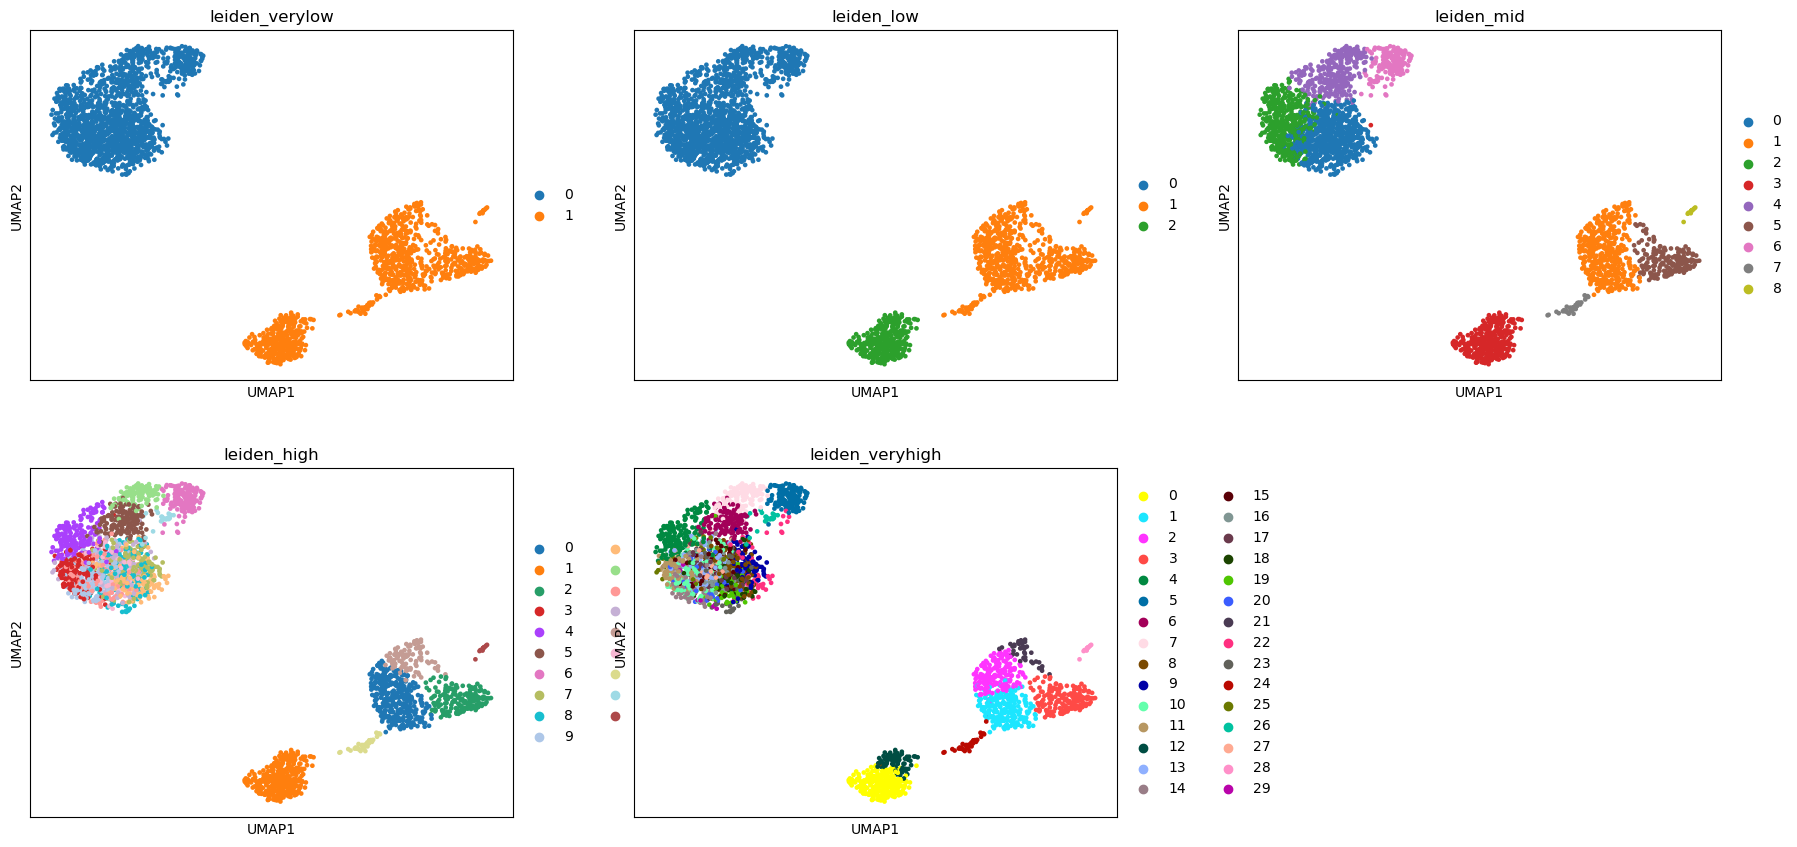

In [17]:
import numpy as np
adata = sc.read_10x_mtx(
    './data/filtered_gene_bc_matrices/hg19/',  # the directory with the `.mtx` file
    var_names='gene_symbols',                  # use gene symbols for the variable names (variables-axis index)
    cache=True)   

adata.var_names_make_unique()  # this is unnecessary if using `var_names='gene_ids'` in `sc.read_10x_mtx`
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)
mito_genes = adata.var_names.str.startswith('MT-')
# for each cell compute fraction of counts in mito genes vs. all genes
# the `.A1` is only necessary as X is sparse (to transform to a dense array after summing)
adata.obs['percent_mito'] = np.sum(
    adata[:, mito_genes].X, axis=1).A1 / np.sum(adata.X, axis=1).A1
# add the total counts per cell as observations-annotation to adata
adata.obs['n_counts'] = adata.X.sum(axis=1)
adata = adata[adata.obs.n_genes < 2500, :]
adata = adata[adata.obs.percent_mito < 0.05, :]
adata.layers['counts'] = adata.X.copy()
adata.raw = adata
sc.pp.highly_variable_genes(adata, n_top_genes=2000, layer='counts',  flavor='seurat_v3',)
adata = adata[:, adata.var.highly_variable]
adata.write_h5ad('data/pbmcs3k_pre.h5ad')
sc.pp.normalize_total(adata, target_sum=1e4)
adata_norm = adata.copy()
sc.pp.log1p(adata)
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, svd_solver='arpack')
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
sc.tl.umap(adata)

# Create leiden clusters for each resolution
for resolution_value, key_name in leiden_resolutions:
    sc.tl.leiden(adata, key_added=key_name, resolution=resolution_value)

# Plot UMAP with all leiden resolutions
sc.pl.umap(adata, color=resolution_keys, ncols=3)

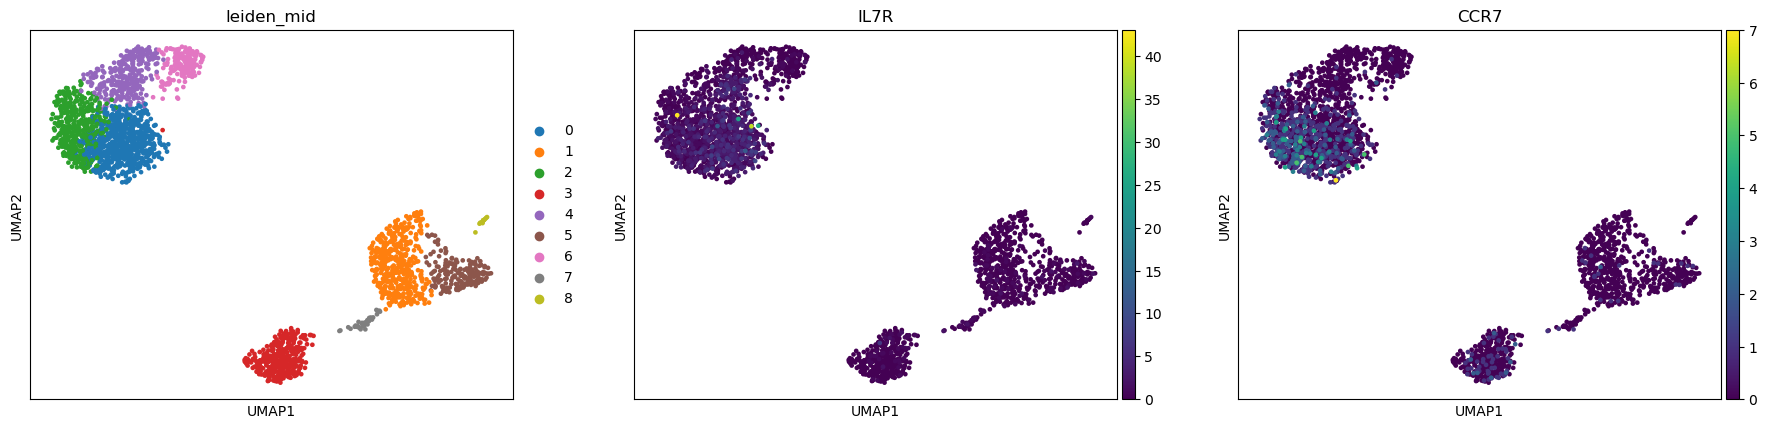

In [5]:
sc.pl.umap(adata, color=['leiden_mid'] + markers['Naive CD4 T'],  use_raw=True)

In [6]:
# Assign clusters to cell types (optional: customize this mapping for your specific resolution)
# This mapping is for the 'leiden_mid' resolution - adjust if using different resolutions
import pandas as pd

# Optional: Define cell type mapping for a specific resolution
# If you want to map cell types, specify which resolution key to use and the mapping
# Example for leiden_mid resolution:
celltype_map = {'0': 'Memory CD4 T', '2': 'Naive CD4 T', '5': 'FCGR3A Mono', '3': 'B', '4': 'CD8 T', '1': 'CD14 Mono', '6': 'NK', '7': 'DC', '8': 'Platelet'}
cell_type_resolution_key = 'leiden_mid'  # Change this to map a different resolution

if cell_type_resolution_key in resolution_keys:
    cell_types = list(celltype_map.values())
    adata.obs['cell_type'] = adata.obs[cell_type_resolution_key].map(celltype_map)
    adata_norm.obs['cell_type'] = adata.obs['cell_type']
else:
    print(f"Warning: {cell_type_resolution_key} not found in resolution_keys. Skipping cell type mapping.")
    cell_types = []

# Sort categories in all leiden resolutions by numerical order
for key_name in resolution_keys:
    adata.obs[key_name] = pd.Categorical(adata.obs[key_name], categories=sorted(adata.obs[key_name].unique()), ordered=True)
    adata_norm.obs[key_name] = adata.obs[key_name]

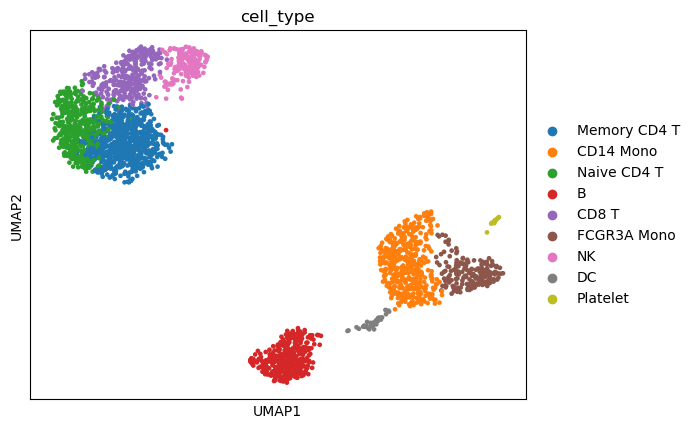

In [7]:
sc.pl.umap(adata, color=['cell_type'])


In [8]:
import importlib
import os

file_path = os.path.join(os.getcwd(), "../../pkg/", "scanpy_wrapper.py")
spec = importlib.util.spec_from_file_location("scanpy_wrapper", file_path)
scanpy_wrapper = importlib.util.module_from_spec(spec)
spec.loader.exec_module(scanpy_wrapper)

In [9]:
# top_genes is defined in the configuration cell at the top

def top_significant_genes(adata, group, top_genes=10, pval_threshold=0.05):
    df = sc.get.rank_genes_groups_df(adata, group=group)
    sig_df = df[df['pvals_adj'] < pval_threshold]
    if sig_df.shape[0] == 0:
        # If there are no significant genes, just return an empty list
        return []
    # Sort by score (descending)
    sig_df = sig_df.sort_values('scores', ascending=False)
    return sig_df['names'].head(top_genes).tolist()

# For each resolution, get the LN signatures from significant genes
ln_signatures = {}
for key_name in resolution_keys:
    clusters = adata_norm.obs[key_name].unique()
    clusters = np.array(sorted(clusters.astype(int))).astype(str)
    scanpy_wrapper.rank_genes_groups_ln(adata_norm, key_name)
    ln_signatures[key_name] = {c: top_significant_genes(adata_norm, c, top_genes=top_genes) for c in clusters}

In [10]:
# For each resolution, get the top scoring significant genes
log1p_signatures = {}
for key_name in resolution_keys:
    clusters = adata.obs[key_name].unique()
    clusters = np.array(sorted(clusters.astype(int))).astype(str)
    sc.tl.rank_genes_groups(adata, key_name)
    log1p_signatures[key_name] = {c: top_significant_genes(adata, c, top_genes=top_genes) for c in clusters}

/Users/pedroferreira/miniconda3/envs/de-ziln/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/Users/pedroferreira/miniconda3/envs/de-ziln/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:460: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/Users/pedroferreira/miniconda3/envs/de-ziln/lib/python3.13/site-packages/scanpy/tools/_ran

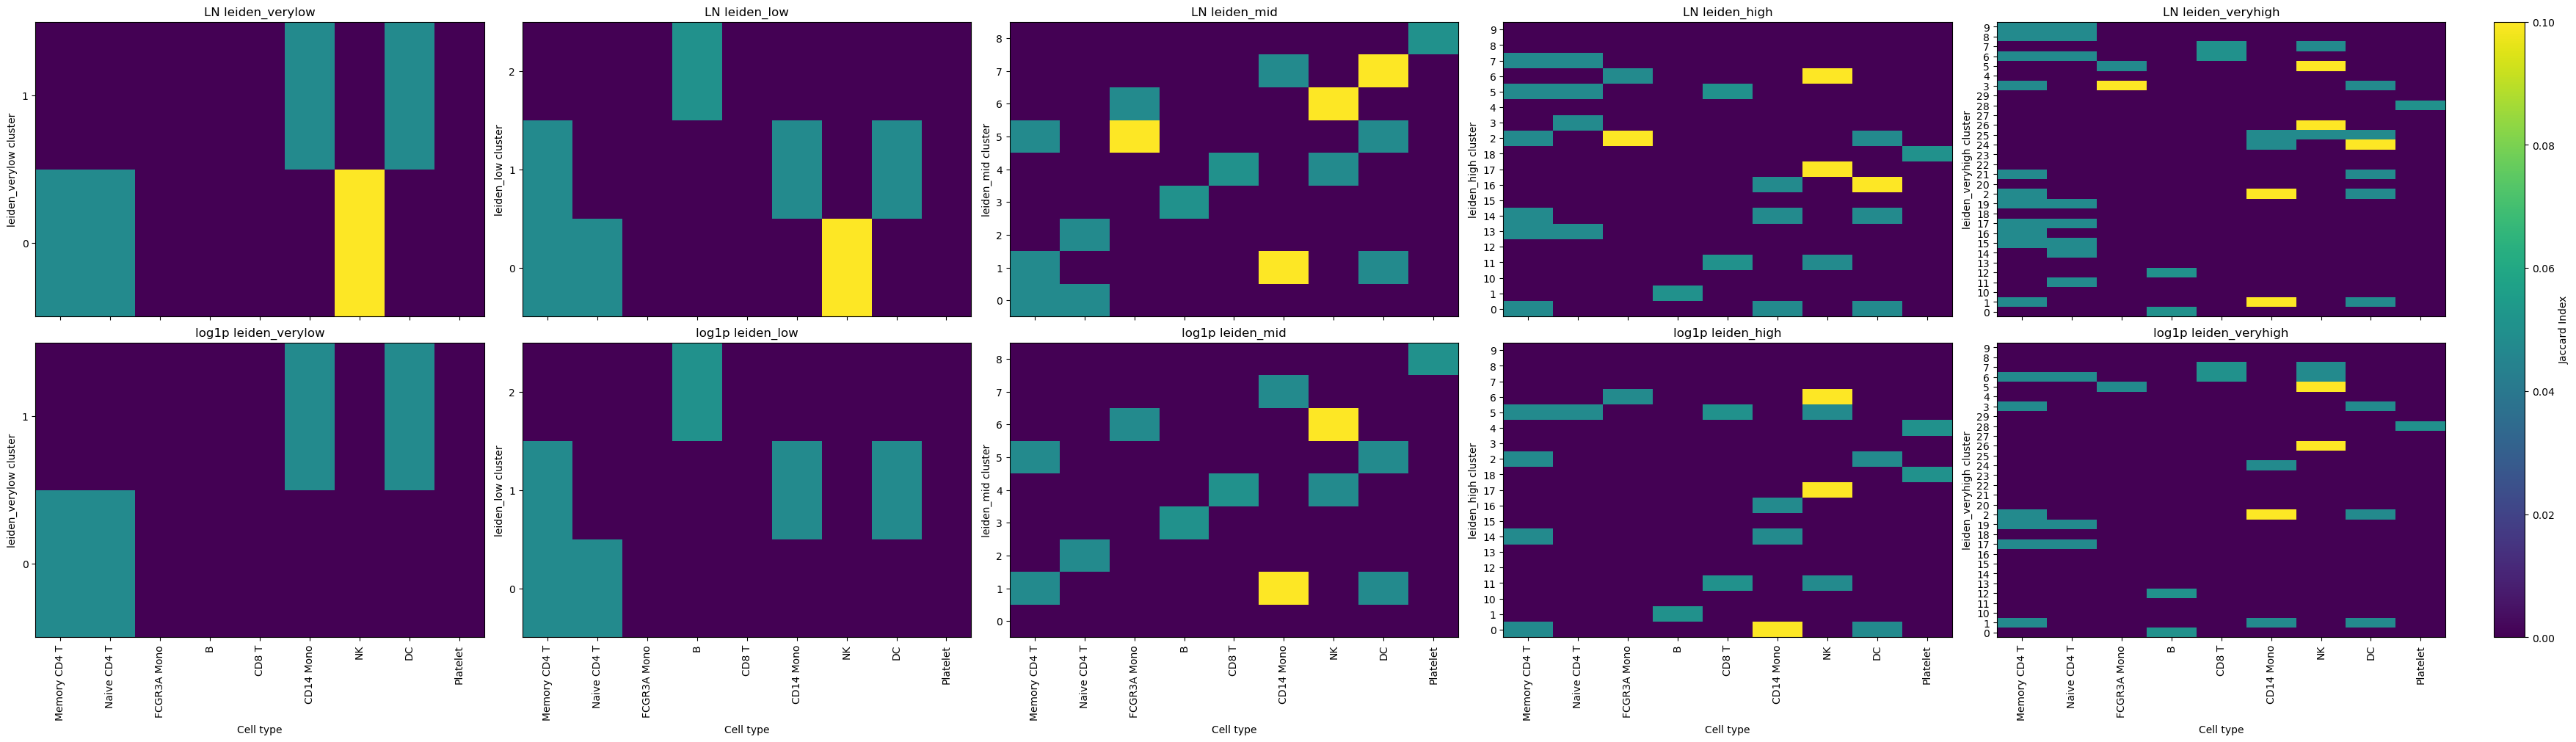

In [11]:
import numpy as np
import matplotlib.pyplot as plt

def compute_jaccard_index(signature_1, signature_2):
    """
    Compute the Jaccard index between two signatures.
    """
    return len(set(signature_1) & set(signature_2)) / len(set(signature_1) | set(signature_2))

# --- Compute LN matrices ---
ln_mats = {}
for key_name in resolution_keys:
    clusters = sorted(ln_signatures[key_name].keys())
    ln_mats[key_name] = np.zeros((len(clusters), len(cell_types)))
    for i, c in enumerate(clusters):
        for j, c2 in enumerate(cell_types):
            ln_mats[key_name][i, j] = compute_jaccard_index(ln_signatures[key_name][c], markers[c2])

# --- Compute log1p matrices ---
log1p_mats = {}
for key_name in resolution_keys:
    clusters = sorted(log1p_signatures[key_name].keys())
    log1p_mats[key_name] = np.zeros((len(clusters), len(cell_types)))
    for i, c in enumerate(clusters):
        for j, c2 in enumerate(cell_types):
            log1p_mats[key_name][i, j] = compute_jaccard_index(log1p_signatures[key_name][c], markers[c2])

# --- Get vmin/vmax for shared color scale ---
all_mats = list(ln_mats.values()) + list(log1p_mats.values())
vmin = min(mat.min() for mat in all_mats)
vmax = max(mat.max() for mat in all_mats)

# --- Plotting ---
n_resolutions = len(resolution_keys)
fig, axes = plt.subplots(2, n_resolutions, figsize=(7*n_resolutions, 10), constrained_layout=True, sharex='col', sharey=False)

# Top row: LN
for col, key_name in enumerate(resolution_keys):
    clusters = sorted(ln_signatures[key_name].keys())
    c = axes[0, col].pcolormesh(ln_mats[key_name], vmin=vmin, vmax=vmax)
    axes[0, col].set_title(f'LN {key_name}')
    axes[0, col].set_ylabel(f'{key_name} cluster')
    axes[0, col].set_yticks(np.arange(len(clusters)) + 0.5)
    axes[0, col].set_yticklabels(clusters)
    axes[0, col].set_xticklabels([])

# Bottom row: log1p
last_c = None
for col, key_name in enumerate(resolution_keys):
    clusters = sorted(log1p_signatures[key_name].keys())
    last_c = axes[1, col].pcolormesh(log1p_mats[key_name], vmin=vmin, vmax=vmax)
    axes[1, col].set_title(f'log1p {key_name}')
    axes[1, col].set_ylabel(f'{key_name} cluster')
    axes[1, col].set_xlabel('Cell type')
    axes[1, col].set_yticks(np.arange(len(clusters)) + 0.5)
    axes[1, col].set_yticklabels(clusters)
    axes[1, col].set_xticks(np.arange(len(cell_types)) + 0.5)
    axes[1, col].set_xticklabels(cell_types, rotation=90)

# Shared colorbar for all
from mpl_toolkits.axes_grid1 import make_axes_locatable
if last_c is not None:
    fig.colorbar(last_c, ax=axes, orientation='vertical', fraction=0.03, pad=0.02, label='Jaccard Index')

plt.show()


In [12]:
# TODO
# Change signature top genes until we get Naive CD4 T and Memory CD4 T signatures also for LN to make mid heatmap look better
# Plot 1: average signature overlap as we increase resolution, after filtering for significance in gene list
# Plot 2: average LFC as we increase resolution, after filtering for significance in gene list

/Users/pedroferreira/miniconda3/envs/de-ziln/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/Users/pedroferreira/miniconda3/envs/de-ziln/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:460: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/Users/pedroferreira/miniconda3/envs/de-ziln/lib/python3.13/site-packages/scanpy/tools/_ran

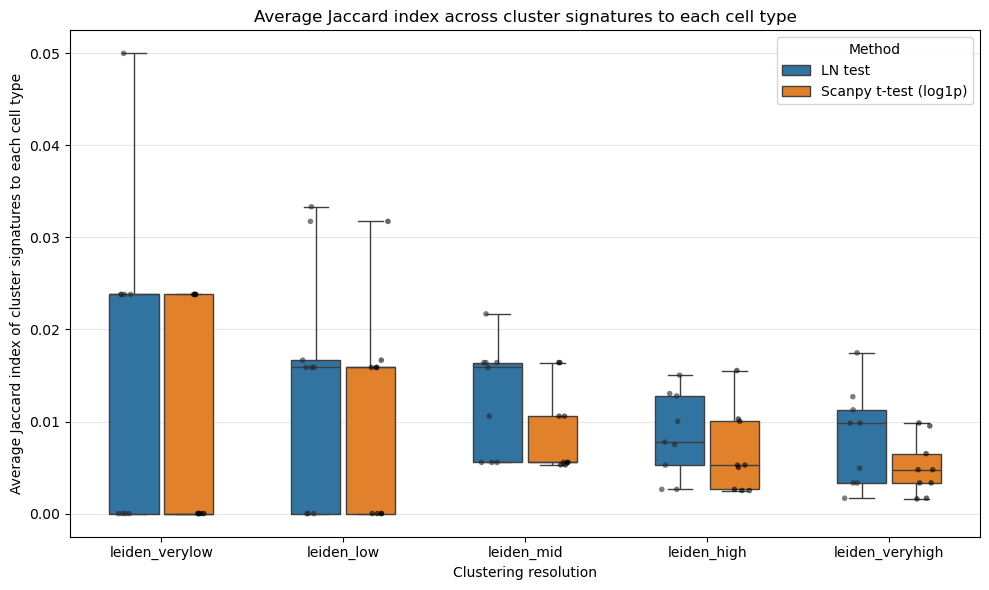

In [13]:
# Plot average Jaccard index of cluster signature vs. reference cell type signatures
# for each cell type, across clustering resolutions. Use seaborn boxplots and overlay stripplot.

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Use the resolution_keys defined at the beginning of the notebook
# res_keys = resolution_keys  # Already defined in configuration cell

# --- SETUP (reference signatures) ---
cell_types = list(markers.keys())
cell_type_signatures = {ct: set(markers[ct]) for ct in cell_types}

# Use top_genes from configuration cell
top_n = top_genes  # number of genes in each cluster signature

records = []
for key in resolution_keys:
    # Clusters present at this resolution
    clusters = sorted([str(x) for x in adata_norm.obs[key].unique()])
    scanpy_wrapper.rank_genes_groups_ln(adata_norm, key, sparse=True)
    import scanpy as sc
    sc.tl.rank_genes_groups(adata, groupby=key, method="t-test", key_added="t_test_results")
    # Build all cluster signatures for this resolution and method (LN and t-test)
    # For each method, for each cell type, compute the *maximum* Jaccard between any cluster signature and the cell type marker set
    # This quantifies, for each cell type, how "best-matching" any cluster is at that resolution
    # (Alternatively, could average, or use another aggregation)
    # Construct list-of-signatures per method
    ln_cluster_signatures = []
    ttest_cluster_signatures = []
    for group in clusters:
        df_ln = sc.get.rank_genes_groups_df(adata_norm, group=group)
        sig_ln = df_ln[df_ln["pvals_adj"] < 0.05].sort_values("scores", ascending=False).head(top_n)
        ln_cluster_signatures.append(set(sig_ln["names"]))
        df_t = sc.get.rank_genes_groups_df(adata, group=group, key="t_test_results")
        sig_t = df_t[df_t["pvals_adj"] < 0.05].sort_values("scores", ascending=False).head(top_n)
        ttest_cluster_signatures.append(set(sig_t["names"]))
    # For each cell type, compute the max jaccard across all clusters for each method
    for ct in cell_types:
        s = cell_type_signatures[ct]
        # LN test
        ln_jaccards = []
        for cluster_signature in ln_cluster_signatures:
            if len(cluster_signature | s) == 0:
                jaccard = np.nan
            else:
                jaccard = len(cluster_signature & s) / len(cluster_signature | s)
            ln_jaccards.append(jaccard)
        if len(ln_jaccards) > 0:
            ln_max_jaccard = np.nanmax(ln_jaccards)
            ln_mean_jaccard = np.nanmean(ln_jaccards)
        else:
            ln_max_jaccard = np.nan
            ln_mean_jaccard = np.nan
        records.append({
            "resolution": key,
            "method": "LN test",
            "cell_type": ct,
            "max_jaccard_sig": ln_max_jaccard,
            "avg_jaccard_sig": ln_mean_jaccard,
        })
        # Scanpy t-test
        t_jaccards = []
        for cluster_signature_t in ttest_cluster_signatures:
            if len(cluster_signature_t | s) == 0:
                jaccard = np.nan
            else:
                jaccard = len(cluster_signature_t & s) / len(cluster_signature_t | s)
            t_jaccards.append(jaccard)
        if len(t_jaccards) > 0:
            t_max_jaccard = np.nanmax(t_jaccards)
            t_mean_jaccard = np.nanmean(t_jaccards)
        else:
            t_max_jaccard = np.nan
            t_mean_jaccard = np.nan
        records.append({
            "resolution": key,
            "method": "Scanpy t-test (log1p)",
            "cell_type": ct,
            "max_jaccard_sig": t_max_jaccard,
            "avg_jaccard_sig": t_mean_jaccard,
        })

# Prepare dataframe for plotting; you can plot avg_jaccard_sig or max_jaccard_sig
df_plot = pd.DataFrame(records)

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_plot,
    x="resolution",
    y="avg_jaccard_sig",
    hue="method",
    width=0.6,
    showfliers=False,
    gap=0.1,
)

# Overlay individual cell type points (scatter, do not add extra legend)
strip_handles = sns.stripplot(
    data=df_plot,
    x="resolution",
    y="avg_jaccard_sig",
    hue="method",
    dodge=True,
    alpha=0.6,
    color='k',
    zorder=10,
    size=4,
)

# Remove the additional legend entries from the stripplot (scatter)
handles, labels = plt.gca().get_legend_handles_labels()
methods = df_plot["method"].unique()
n_methods = len(methods)
plt.legend(handles[:n_methods], labels[:n_methods], title="Method", loc="upper right")

plt.ylabel("Average Jaccard index of cluster signatures to each cell type")
plt.xlabel("Clustering resolution")
plt.title(f"Average Jaccard index across cluster signatures to each cell type")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

/Users/pedroferreira/miniconda3/envs/de-ziln/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/Users/pedroferreira/miniconda3/envs/de-ziln/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:460: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/Users/pedroferreira/miniconda3/envs/de-ziln/lib/python3.13/site-packages/scanpy/tools/_ran

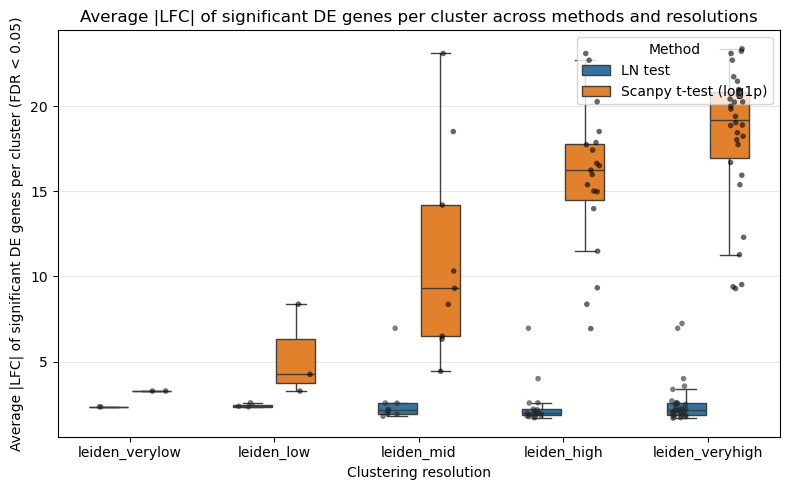

In [15]:
# Plot average LFC of significant DE genes (FDR < 0.05) per cluster across resolutions
# For both LN test and Scanpy's default (log1p-t test) using seaborn boxplots side by side

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Use the resolution_keys defined at the beginning of the notebook
# res_keys = resolution_keys  # Already defined in configuration cell

# Collect results for both methods
records = []
for key in resolution_keys:
    import scanpy as sc
    # Run LN test
    import importlib
    import os
    file_path = os.path.join(os.getcwd(), "../../pkg/", "scanpy_wrapper.py")
    spec = importlib.util.spec_from_file_location("scanpy_wrapper", file_path)
    scanpy_wrapper = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(scanpy_wrapper)
    scanpy_wrapper.rank_genes_groups_ln(adata_norm, key, sparse=True)
    # Run t-test using Scanpy
    sc.tl.rank_genes_groups(adata, groupby=key, method="t-test", key_added="t_test_results")

    # Get groups (clusters) present at this resolution
    clusters = sorted([str(x) for x in adata_norm.obs[key].unique()])
    for group in clusters:
        # LN test
        df_ln = sc.get.rank_genes_groups_df(adata_norm, group=group)
        sig_ln = df_ln[df_ln["pvals_adj"] < 0.05]
        if len(sig_ln) > 0:
            avg_lfc_ln = sig_ln["logfoldchanges"].abs().mean()
        else:
            avg_lfc_ln = np.nan
        records.append({
            "resolution": key,
            "method": "LN test",
            "avg_abs_lfc_sig": avg_lfc_ln,
            "cluster": group,
        })
        # t-test (Scanpy)
        df_t = sc.get.rank_genes_groups_df(adata, group=group, key="t_test_results")
        sig_t = df_t[df_t["pvals_adj"] < 0.05]
        if len(sig_t) > 0:
            avg_lfc_t = sig_t["logfoldchanges"].abs().mean()
            # estimated_lfc = lt - lc
            # log_x_t, log_x_c = np.log(1 + x_treatment), np.log(1 + x_ctrl)
            # lt, lc = np.mean(log_x_t), np.mean(log_x_c)
        else:
            avg_lfc_t = np.nan
        records.append({
            "resolution": key,
            "method": "Scanpy t-test (log1p)",
            "avg_abs_lfc_sig": avg_lfc_t,
            "cluster": group,
        })

# Create DataFrame for seaborn
df_plot = pd.DataFrame(records)

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_plot,
    x="resolution",
    y="avg_abs_lfc_sig",
    hue="method",
    width=0.6,
    showfliers=False,
    gap=0.1,
)

# Overlay scatter for every cluster WITHOUT adding scatter to the legend
strip_handles = sns.stripplot(
    data=df_plot,
    x="resolution",
    y="avg_abs_lfc_sig",
    hue="method",
    dodge=True,
    alpha=0.6,
    color='k',
    zorder=10,
    size=4,
)

# Remove the additional legend entries from the stripplot (scatter)
# Keep only one legend (for methods) from the boxplot
handles, labels = plt.gca().get_legend_handles_labels()
methods = df_plot["method"].unique()
n_methods = len(methods)
plt.legend(handles[:n_methods], labels[:n_methods], title="Method", loc="upper right")

plt.ylabel("Average |LFC| of significant DE genes per cluster (FDR < 0.05)")
plt.xlabel("Clustering resolution")
plt.title("Average |LFC| of significant DE genes per cluster across methods and resolutions")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

/Users/pedroferreira/miniconda3/envs/de-ziln/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/Users/pedroferreira/miniconda3/envs/de-ziln/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:460: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/Users/pedroferreira/miniconda3/envs/de-ziln/lib/python3.13/site-packages/scanpy/tools/_ran

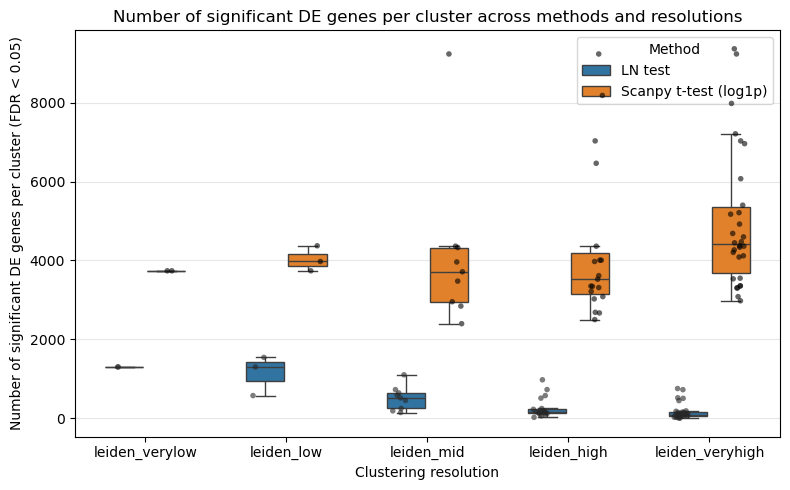

In [16]:
# Plot number of significant DE genes (FDR < 0.05) per cluster across resolutions
# For both LN test and Scanpy's default (log1p-t test) using seaborn boxplots side by side

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Collect results for both methods
records = []
for key in resolution_keys:
    import scanpy as sc
    # Run LN test
    import importlib
    import os
    file_path = os.path.join(os.getcwd(), "../../pkg/", "scanpy_wrapper.py")
    spec = importlib.util.spec_from_file_location("scanpy_wrapper", file_path)
    scanpy_wrapper = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(scanpy_wrapper)
    scanpy_wrapper.rank_genes_groups_ln(adata_norm, key, sparse=True)
    # Run t-test using Scanpy
    sc.tl.rank_genes_groups(adata, groupby=key, method="t-test", key_added="t_test_results")

    # Get groups (clusters) present at this resolution
    clusters = sorted([str(x) for x in adata_norm.obs[key].unique()])
    for group in clusters:
        # LN test
        df_ln = sc.get.rank_genes_groups_df(adata_norm, group=group)
        n_sig_ln = (df_ln["pvals_adj"] < 0.05).sum()
        records.append({
            "resolution": key,
            "method": "LN test",
            "n_sig_genes": n_sig_ln,
            "cluster": group,
        })
        # t-test (Scanpy)
        df_t = sc.get.rank_genes_groups_df(adata, group=group, key="t_test_results")
        n_sig_t = (df_t["pvals_adj"] < 0.05).sum()
        records.append({
            "resolution": key,
            "method": "Scanpy t-test (log1p)",
            "n_sig_genes": n_sig_t,
            "cluster": group,
        })

# Create DataFrame for seaborn
df_plot = pd.DataFrame(records)

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_plot,
    x="resolution",
    y="n_sig_genes",
    hue="method",
    width=0.6,
    showfliers=False,
    gap=0.1,
)

# Overlay scatter for every cluster WITHOUT adding scatter to the legend
strip_handles = sns.stripplot(
    data=df_plot,
    x="resolution",
    y="n_sig_genes",
    hue="method",
    dodge=True,
    alpha=0.6,
    color='k',
    zorder=10,
    size=4,
)

# Remove the additional legend entries from the stripplot (scatter)
# Keep only one legend (for methods) from the boxplot
handles, labels = plt.gca().get_legend_handles_labels()
# With seaborn >= 0.12, often the first len(methods) handles belong to boxplot, then to stripplot
# Let's keep only unique methods/types:
methods = df_plot["method"].unique()
n_methods = len(methods)
# Only keep first n_methods handles/labels
plt.legend(handles[:n_methods], labels[:n_methods], title="Method", loc="upper right")

plt.ylabel("Number of significant DE genes per cluster (FDR < 0.05)")
plt.xlabel("Clustering resolution")
plt.title("Number of significant DE genes per cluster across methods and resolutions")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()